PHASE 3: UNIVARIANT ANALYSIS(One Feature at a time)

Goal:

Analyze one feature at a time and answer:

- What does it look like?
- What's the distribution?
- Is it skewed?
- Are there outliers?
- Does it make sense?
- Does it need preprocessing later?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as st
import seaborn as sns

In [ ]:
# 3.0 data loading (load from phase 2- cleaned dataset)

df = pd.read_csv(r'D:\chennai1-pg-price-predictor\Data\processed\EDA\01_eda_Phase-2_processed.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   latitude                 1436 non-null   float64
 1   longitude                1436 non-null   float64
 2   locality                 1436 non-null   object 
 3   gender                   1436 non-null   object 
 4   available_for            1436 non-null   object 
 5   transit_score            1436 non-null   float64
 6   lifestyle_score          1436 non-null   float64
 7   occupancy                1436 non-null   object 
 8   rent                     1436 non-null   float64
 9   deposit                  1436 non-null   float64
 10  attached_bathroom        1436 non-null   bool   
 11  food_included            1436 non-null   bool   
 12  breakfast                1436 non-null   bool   
 13  lunch                    1436 non-null   bool   
 14  dinner                  

In [4]:
# 3.1 Seperate Columns

num_cols = df.select_dtypes(include=['number']).columns.to_list()
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.to_list()

3.1 Univariant analysis for numerical columns

In [5]:
# helper functions

def analyze_numeric(df: pd.DataFrame, column):
    """
    Perform univariate analysis on a numerical column.
    Displays:
    - Histogram + KDE
    - Boxplot
    - Summary statistics
    - Five-number summary
    - Distribution metrics
    - Outlier statistics (IQR method)
    """
    data = df[column]
    sns.set_theme(style='whitegrid')
    fig, axes = plt.subplots(1,2, figsize=(14, 5))

    # histogram
    """
    CONCEPT: Histogram + KDE

    A histogram divides values into bins (ranges) and counts how many
    rows fall into each bin. Taller bars = more listings at that rent level.
    """

    sns.histplot(
        data = df,
        x = column,
        bins = 30,
        kde = True,
        ax = axes[0]
    )
    axes[0].set_title(f'{column} Distribution')
    axes[0].set_xlabel(column)

    # Boxplot
    
    """    
    CONCEPT: Box Plot
    A box plot shows the same data in a different way:

    - The box covers the middle 50% of values (25th to 75th percentile)
    - The line inside the box = median (50th percentile)
    - The whiskers extend to 1.5x the box height above and below
    - Dots beyond the whiskers = outliers
    """

    sns.boxplot(
        data = df,
        x = column,
        ax = axes[1]
    )

    axes[1].set_title(f'{column} Boxplot')

    plt.tight_layout()
    plt.show()
    plt.close()

    # Five Number Summary
    minimum = data.min()
    Q1 = data.quantile(0.25)
    median = data.median()
    Q3 = data.quantile(0.75)
    maximum = data.max()

    # IQR
    IQR = Q3 - Q1
    LOWER_FENCE = Q1 - 1.5 * IQR
    UPPER_FENCE = Q3 + 1.5 * IQR

    OUTLIERS = data[
        (data < LOWER_FENCE) | (data > UPPER_FENCE)
    ]

    # Statistics
    print("=" * 50)
    print(f"{column.upper()}") 
    print("=" * 50)

    print("\nBasic Statistics")
    print("-" * 25)
    print(f"Count      : {data.count()}")
    print(f"Missing    : {df[column].isna().sum()}")
    print(f"Mean       : {data.mean():.2f}")
    print(f"Median     : {median:.2f}")
    print(f"Mode       : {data.mode().iloc[0]}")
    print(f"Std Dev    : {data.std():.2f}")

    print("\nFive Number Summary")
    print("-" * 25)
    print(f"Minimum    : {minimum}")
    print(f"Q1 (25%)   : {Q1}")
    print(f"Median     : {median}")
    print(f"Q3 (75%)   : {Q3}")
    print(f"Maximum    : {maximum}")

    print("\nDistribution")
    print("-" * 25)
    print(f"Skewness   : {data.skew():.2f}")
    print(f"Kurtosis   : {data.kurt():.2f}")

    print("\nOutlier Analysis (IQR Method)")
    print("-" * 25)
    print(f"IQR            : {IQR:.2f}")
    print(f"Lower Bound    : {LOWER_FENCE:.2f}")
    print(f"Upper Bound    : {UPPER_FENCE:.2f}")
    print(f"No. of Outliers: {len(OUTLIERS)}")
    print(f"% of Outliers  : {(len(OUTLIERS)/len(data))*100:.2f}%")

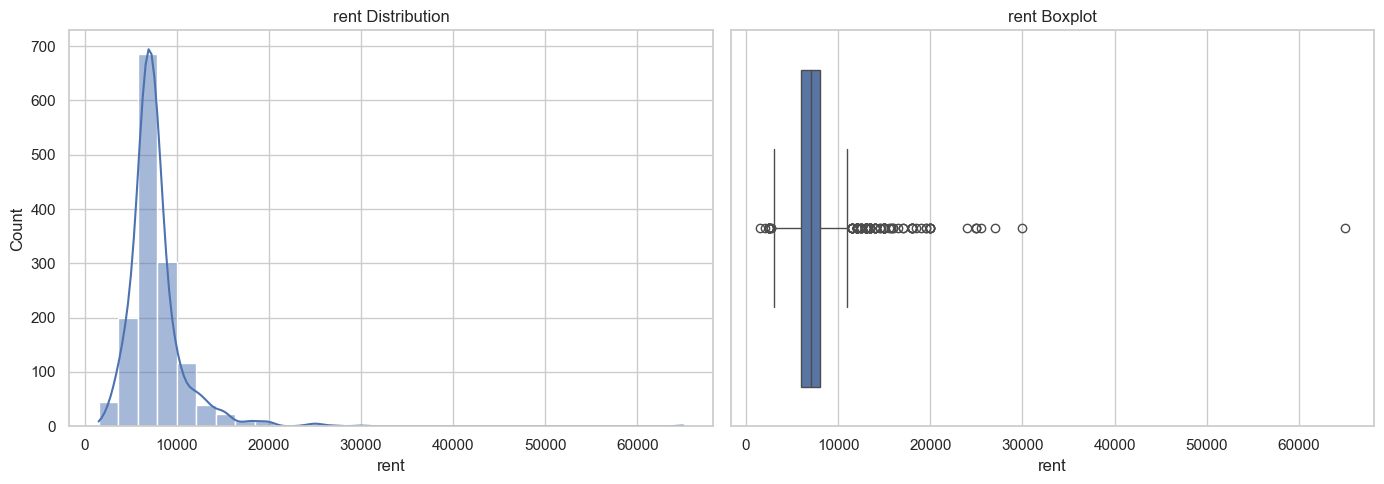

RENT

Basic Statistics
-------------------------
Count      : 1436
Missing    : 0
Mean       : 7668.79
Median     : 7000.00
Mode       : 7000.0
Std Dev    : 3237.03

Five Number Summary
-------------------------
Minimum    : 1500.0
Q1 (25%)   : 6000.0
Median     : 7000.0
Q3 (75%)   : 8050.0
Maximum    : 65000.0

Distribution
-------------------------
Skewness   : 5.50
Kurtosis   : 73.95

Outlier Analysis (IQR Method)
-------------------------
IQR            : 2050.00
Lower Bound    : 2925.00
Upper Bound    : 11125.00
No. of Outliers: 134
% of Outliers  : 9.33%


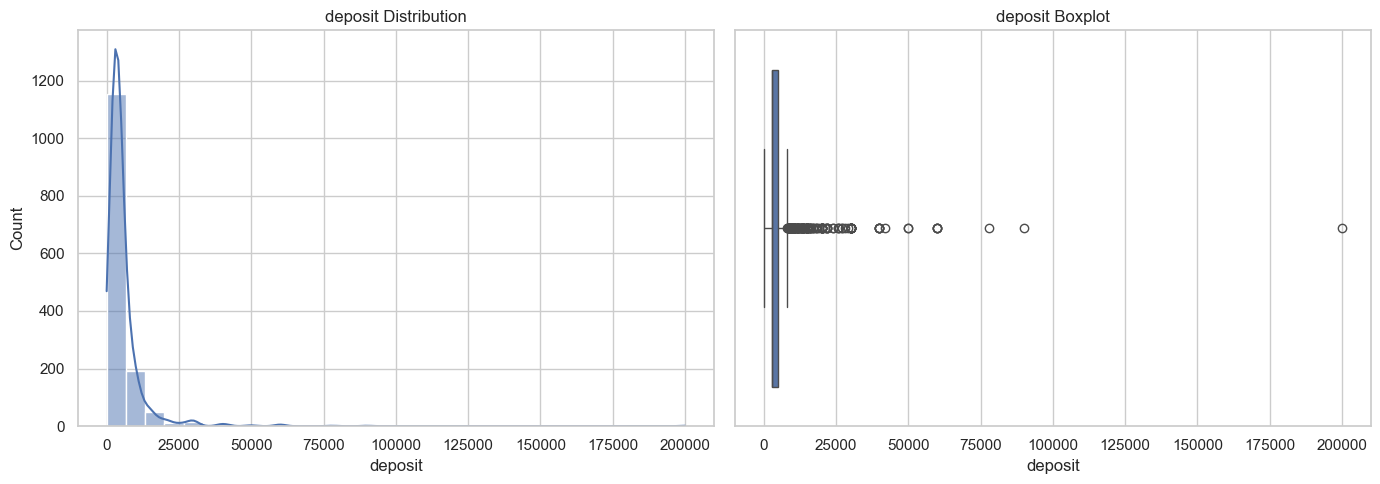

DEPOSIT

Basic Statistics
-------------------------
Count      : 1436
Missing    : 0
Mean       : 5637.16
Median     : 3000.00
Mode       : 3000.0
Std Dev    : 8418.24

Five Number Summary
-------------------------
Minimum    : 1.0
Q1 (25%)   : 3000.0
Median     : 3000.0
Q3 (75%)   : 5000.0
Maximum    : 200000.0

Distribution
-------------------------
Skewness   : 11.37
Kurtosis   : 214.89

Outlier Analysis (IQR Method)
-------------------------
IQR            : 2000.00
Lower Bound    : 0.00
Upper Bound    : 8000.00
No. of Outliers: 210
% of Outliers  : 14.62%


In [6]:
columns = ['rent', 'deposit']
for col in columns:
    analyze_numeric(df, col)

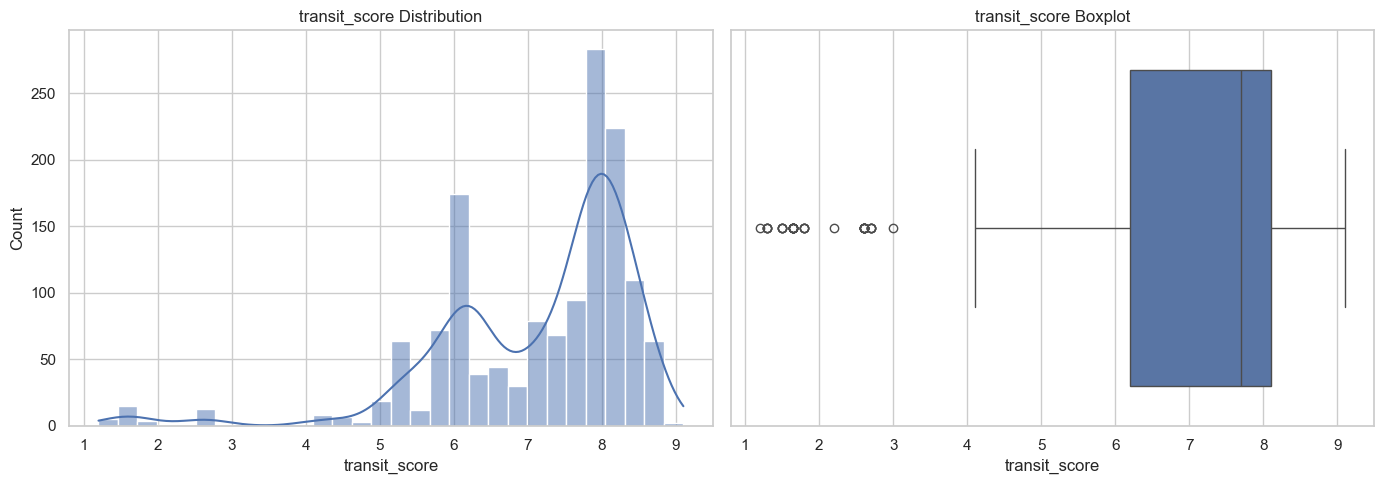

TRANSIT_SCORE

Basic Statistics
-------------------------
Count      : 1436
Missing    : 0
Mean       : 7.14
Median     : 7.70
Mode       : 6.2
Std Dev    : 1.35

Five Number Summary
-------------------------
Minimum    : 1.2
Q1 (25%)   : 6.2
Median     : 7.7
Q3 (75%)   : 8.1
Maximum    : 9.1

Distribution
-------------------------
Skewness   : -1.71
Kurtosis   : 4.04

Outlier Analysis (IQR Method)
-------------------------
IQR            : 1.90
Lower Bound    : 3.35
Upper Bound    : 10.95
No. of Outliers: 39
% of Outliers  : 2.72%


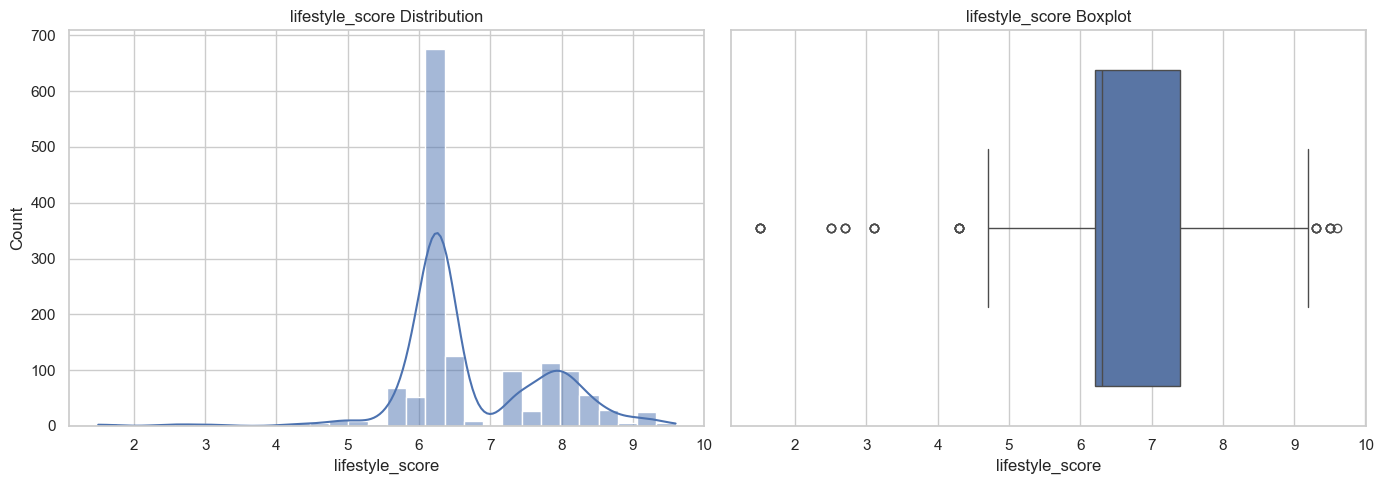

LIFESTYLE_SCORE

Basic Statistics
-------------------------
Count      : 1436
Missing    : 0
Mean       : 6.72
Median     : 6.30
Mode       : 6.3
Std Dev    : 1.04

Five Number Summary
-------------------------
Minimum    : 1.5
Q1 (25%)   : 6.2
Median     : 6.3
Q3 (75%)   : 7.4
Maximum    : 9.6

Distribution
-------------------------
Skewness   : -0.16
Kurtosis   : 2.72

Outlier Analysis (IQR Method)
-------------------------
IQR            : 1.20
Lower Bound    : 4.40
Upper Bound    : 9.20
No. of Outliers: 30
% of Outliers  : 2.09%


In [7]:
columns = ['transit_score','lifestyle_score']
for col in columns:
    analyze_numeric(df,col)
    

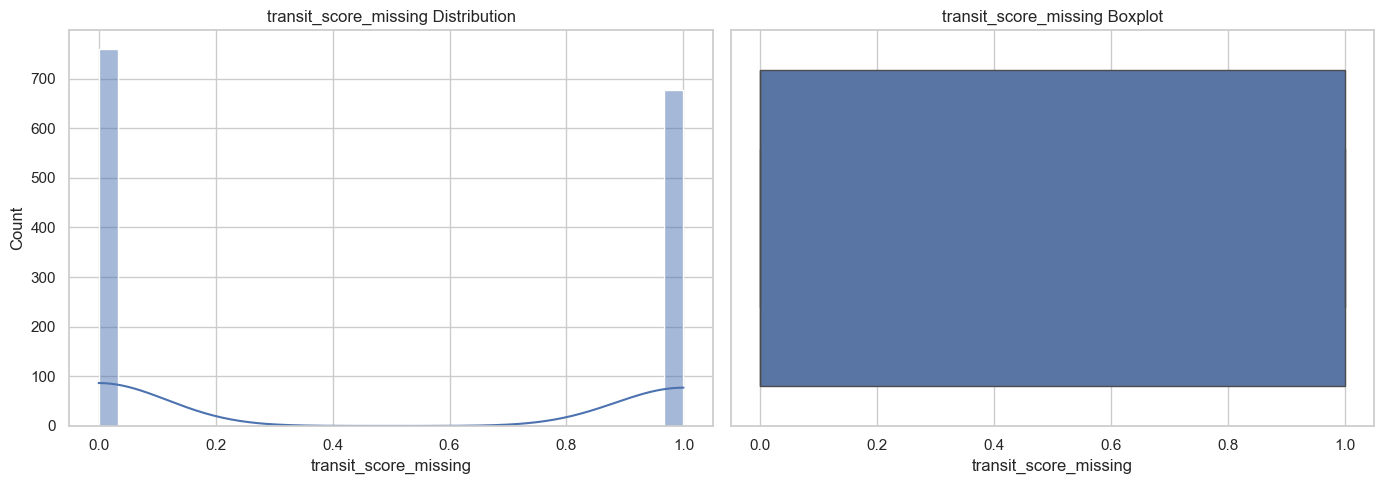

TRANSIT_SCORE_MISSING

Basic Statistics
-------------------------
Count      : 1436
Missing    : 0
Mean       : 0.47
Median     : 0.00
Mode       : 0
Std Dev    : 0.50

Five Number Summary
-------------------------
Minimum    : 0
Q1 (25%)   : 0.0
Median     : 0.0
Q3 (75%)   : 1.0
Maximum    : 1

Distribution
-------------------------
Skewness   : 0.11
Kurtosis   : -1.99

Outlier Analysis (IQR Method)
-------------------------
IQR            : 1.00
Lower Bound    : -1.50
Upper Bound    : 2.50
No. of Outliers: 0
% of Outliers  : 0.00%


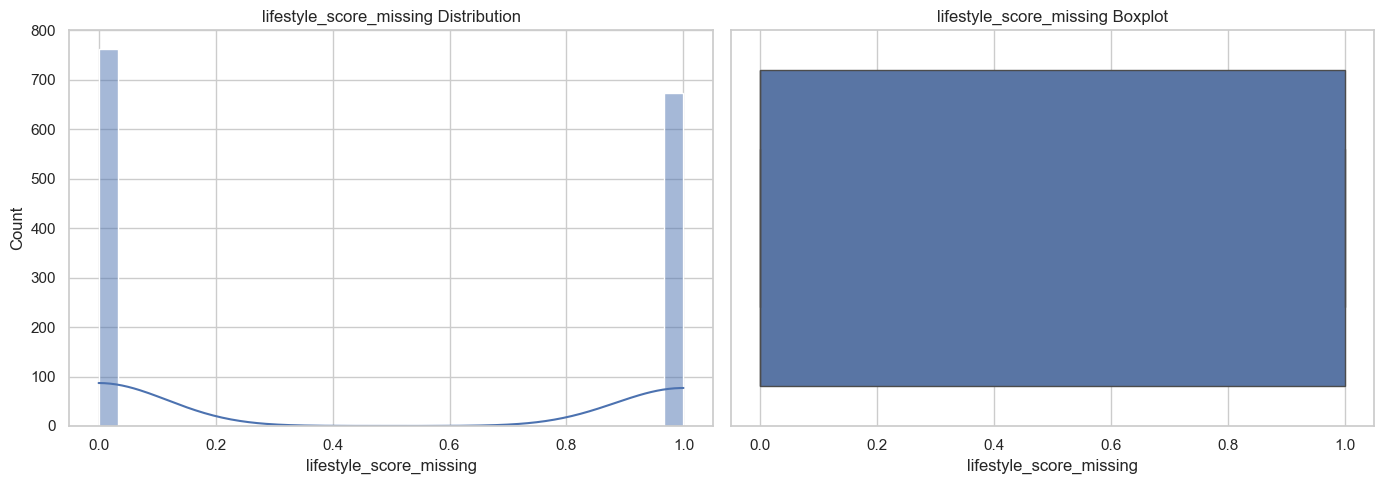

LIFESTYLE_SCORE_MISSING

Basic Statistics
-------------------------
Count      : 1436
Missing    : 0
Mean       : 0.47
Median     : 0.00
Mode       : 0
Std Dev    : 0.50

Five Number Summary
-------------------------
Minimum    : 0
Q1 (25%)   : 0.0
Median     : 0.0
Q3 (75%)   : 1.0
Maximum    : 1

Distribution
-------------------------
Skewness   : 0.12
Kurtosis   : -1.99

Outlier Analysis (IQR Method)
-------------------------
IQR            : 1.00
Lower Bound    : -1.50
Upper Bound    : 2.50
No. of Outliers: 0
% of Outliers  : 0.00%


In [8]:
# Scores missing tag

columns = ['transit_score_missing', 'lifestyle_score_missing']
for col in columns:
    analyze_numeric(df, col)

## 3.2 Univariante Analysis for Categorical Column

In [9]:
def analyze_categorical(df,column):
    counts = df[column].value_counts(dropna=False)
    percentages = df[column].value_counts(normalize=True,dropna=False)*100
    
    summary = (
        pd.DataFrame({
            "Count" : counts,
            "Percentage" : percentages.round(2)
        })
    )
    
    print(f"\n===== {column} =====")
    display(summary)

    plt.figure(figsize=(6,4))
    counts.plot(kind="bar")
    plt.title(f"{column}Distribution")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

    print(f"Unique Categories : {df[column].unique()}")
    print(f"Missing Values : {df[column].isna().sum()}")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   latitude                 1436 non-null   float64
 1   longitude                1436 non-null   float64
 2   locality                 1436 non-null   object 
 3   gender                   1436 non-null   object 
 4   available_for            1436 non-null   object 
 5   transit_score            1436 non-null   float64
 6   lifestyle_score          1436 non-null   float64
 7   occupancy                1436 non-null   object 
 8   rent                     1436 non-null   float64
 9   deposit                  1436 non-null   float64
 10  attached_bathroom        1436 non-null   bool   
 11  food_included            1436 non-null   bool   
 12  breakfast                1436 non-null   bool   
 13  lunch                    1436 non-null   bool   
 14  dinner                  


===== locality =====


,Count,Percentage
locality,,
Tharamani,268,18.66
OMR-Karappakam,223,15.53
Velachery,215,14.97
Vadapalani,83,5.78
Sholinganallur,82,5.71
New Perungalathur,61,4.25
East Coast Road-Thiruvanmiyur,51,3.55
Guindy,47,3.27
Tambaram,46,3.20


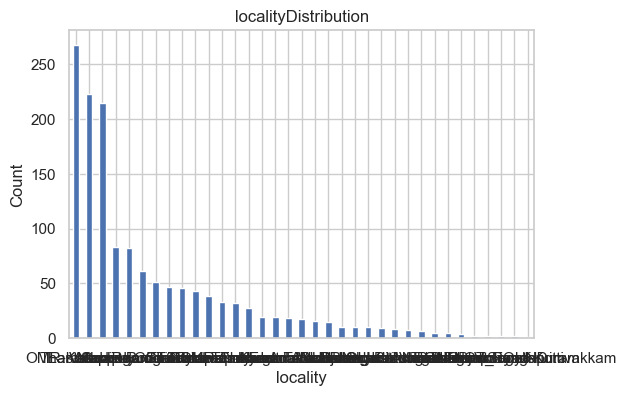

Unique Categories : ['Balaji Nagar' 'Shanthi Nagar' 'New Perungalathur' 'Vandalur'
 'Peerakankaranai' 'Perungalathur' 'Old Perungalathur' 'East Tambaram'
 'Tambaram' 'Tambaram West' 'GST Road-Tambaram' 'Varadharajapuram'
 'Tambaram Sanatoruim' 'Sholinganallur' 'Karapakkam' 'OMR-Karappakam'
 'OMR-Sholinganallur' 'Tharamani' 'Perungudi' 'Thiruvanmiyur'
 'Indian Institute Of Technology' 'East Coast Road-Thiruvanmiyur'
 'Velachery' 'Adambakkam' 'NOT_FOUND' 'East Coast Road-Kottivakkam' 'TNHB'
 'Alandur' 'Guindy' 'Saidapet' 'Vinayagapuram' 'Vadapalani'
 'Arcot Road-Kodambakkam' 'Kodambakkam' 'Ashok Nagar']
Missing Values : 0


In [11]:
analyze_categorical(df,column=('locality'))


===== gender =====


,Count,Percentage
gender,,
MALE,717,49.93
FEMALE,684,47.63
BOTH,35,2.44


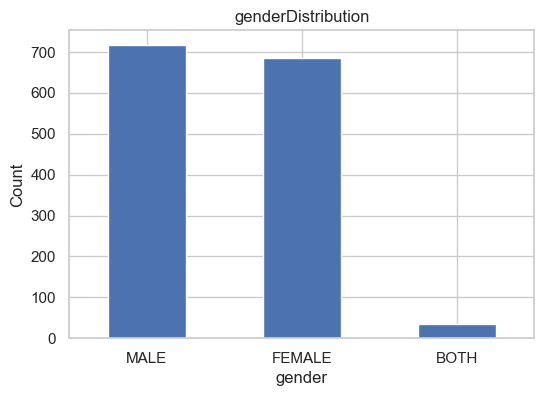

Unique Categories : ['MALE' 'BOTH' 'FEMALE']
Missing Values : 0


In [12]:
analyze_categorical(df, column=('gender'))


===== occupancy =====


,Count,Percentage
occupancy,,
THREE,459,31.96
FOUR,403,28.06
DOUBLE,387,26.95
SINGLE,187,13.02


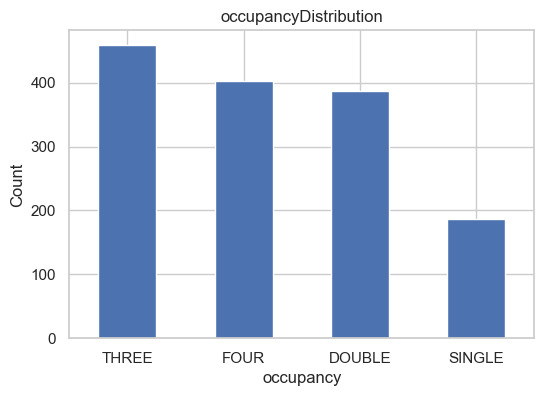

Unique Categories : ['DOUBLE' 'THREE' 'FOUR' 'SINGLE']
Missing Values : 0


In [13]:
analyze_categorical(df, column=('occupancy'))


===== available_for =====


,Count,Percentage
available_for,,
Both,1307,91.02
Working Professional,121,8.43
Student,8,0.56


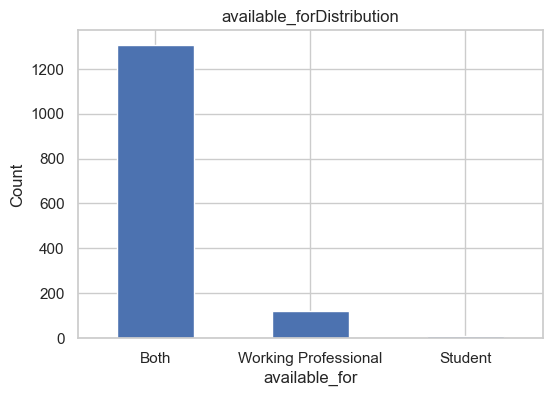

Unique Categories : ['Both' 'Working Professional' 'Student']
Missing Values : 0


In [14]:
analyze_categorical(df, column=('available_for'))


===== occupancy =====


,Count,Percentage
occupancy,,
THREE,459,31.96
FOUR,403,28.06
DOUBLE,387,26.95
SINGLE,187,13.02


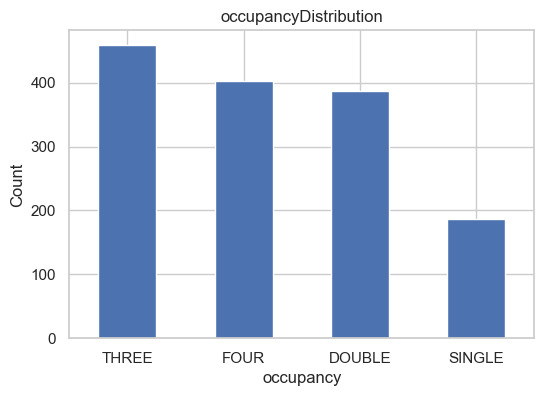

Unique Categories : ['DOUBLE' 'THREE' 'FOUR' 'SINGLE']
Missing Values : 0


In [15]:
analyze_categorical(df, column=('occupancy'))


===== parking =====


,Count,Percentage
parking,,
Bike,1156,80.50
Bike and Car,137,9.54
none,112,7.80
Car,31,2.16


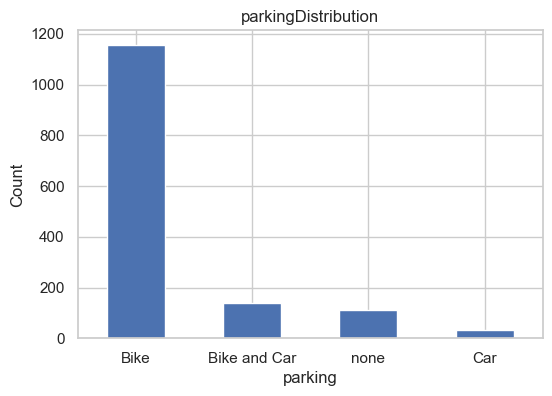

Unique Categories : ['Bike' 'Bike and Car' 'none' 'Car']
Missing Values : 0


In [16]:
analyze_categorical(df, column=('parking'))

# 3.3 univariate analysis for Boolean columns


===== attached_bathroom =====


,Count,Percentage
attached_bathroom,,
False,1072,74.65
True,364,25.35


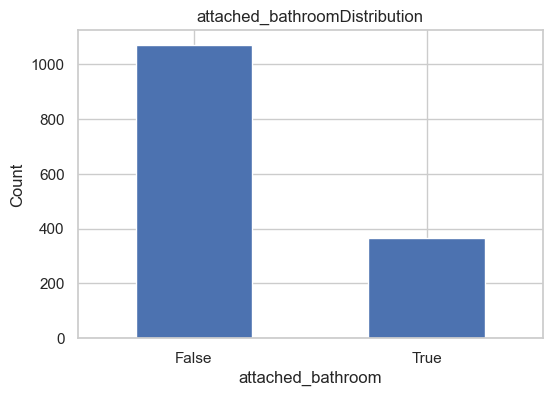

Unique Categories : [False  True]
Missing Values : 0

===== food_included =====


,Count,Percentage
food_included,,
True,1104,76.88
False,332,23.12


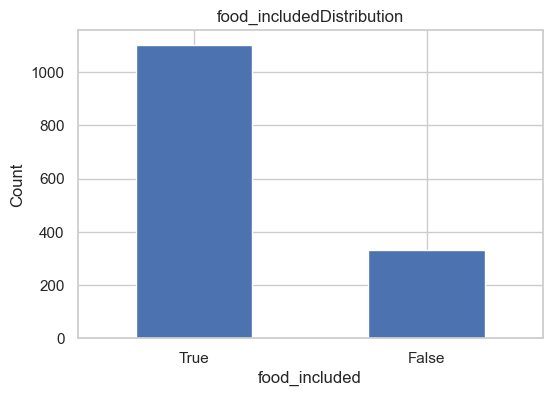

Unique Categories : [ True False]
Missing Values : 0

===== breakfast =====


,Count,Percentage
breakfast,,
True,1085,75.56
False,351,24.44


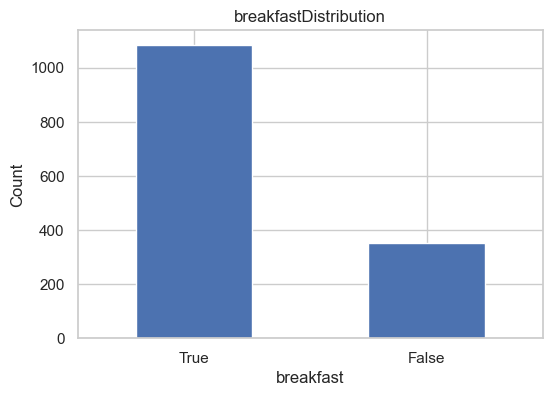

Unique Categories : [ True False]
Missing Values : 0

===== lunch =====


,Count,Percentage
lunch,,
True,1063,74.03
False,373,25.97


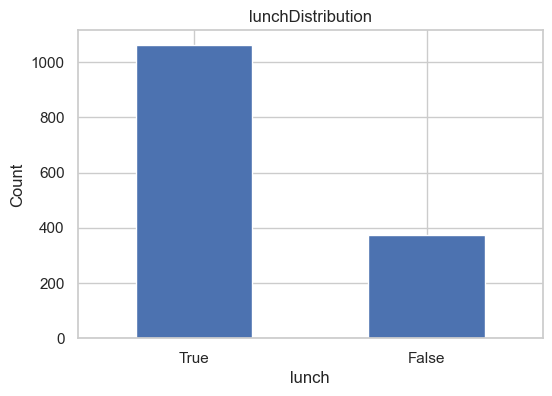

Unique Categories : [ True False]
Missing Values : 0

===== dinner =====


,Count,Percentage
dinner,,
True,1085,75.56
False,351,24.44


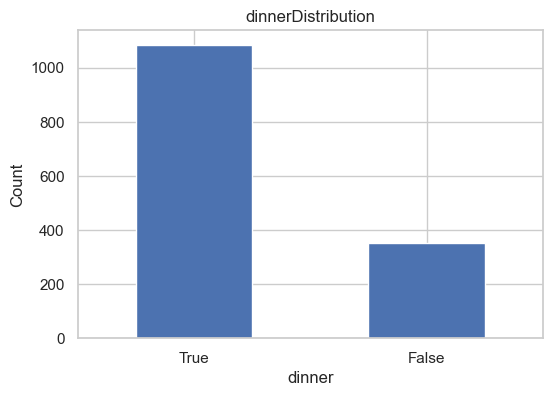

Unique Categories : [ True False]
Missing Values : 0

===== mess =====


,Count,Percentage
mess,,
False,1107,77.09
True,329,22.91


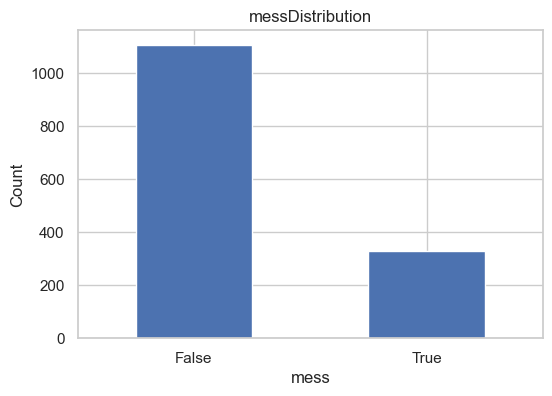

Unique Categories : [False  True]
Missing Values : 0

===== wifi =====


,Count,Percentage
wifi,,
False,870,60.58
True,566,39.42


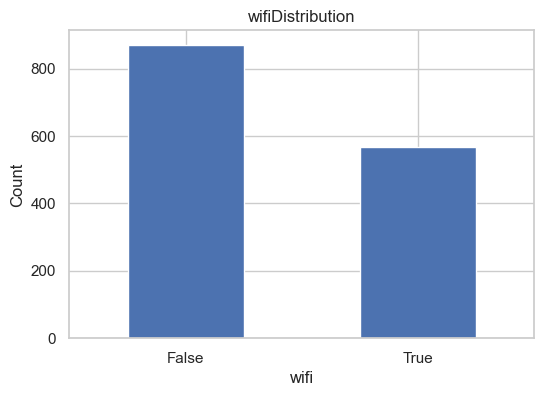

Unique Categories : [False  True]
Missing Values : 0

===== laundry =====


,Count,Percentage
laundry,,
False,1059,73.75
True,377,26.25


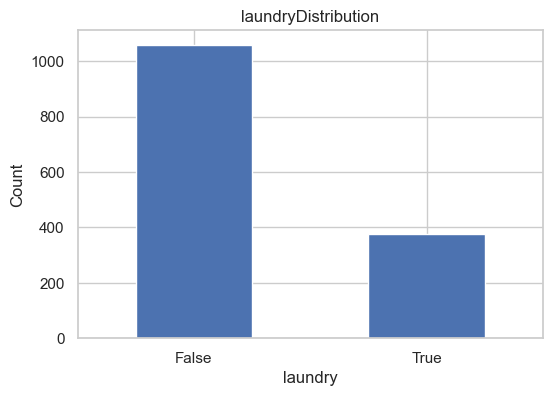

Unique Categories : [False  True]
Missing Values : 0

===== power_backup =====


,Count,Percentage
power_backup,,
False,1275,88.79
True,161,11.21


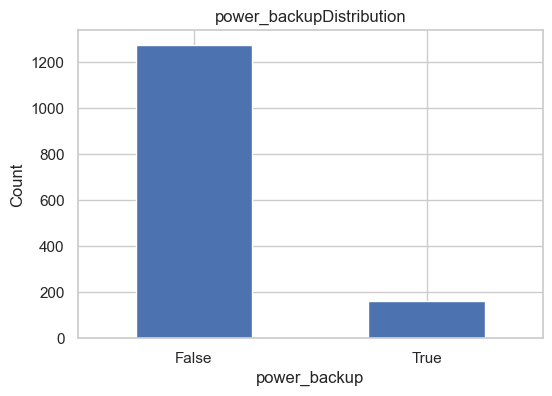

Unique Categories : [False  True]
Missing Values : 0

===== refrigerator =====


,Count,Percentage
refrigerator,,
False,998,69.5
True,438,30.5


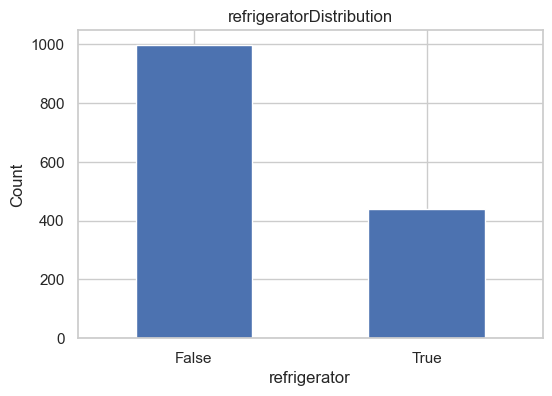

Unique Categories : [False  True]
Missing Values : 0

===== common_tv =====


,Count,Percentage
common_tv,,
False,1138,79.25
True,298,20.75


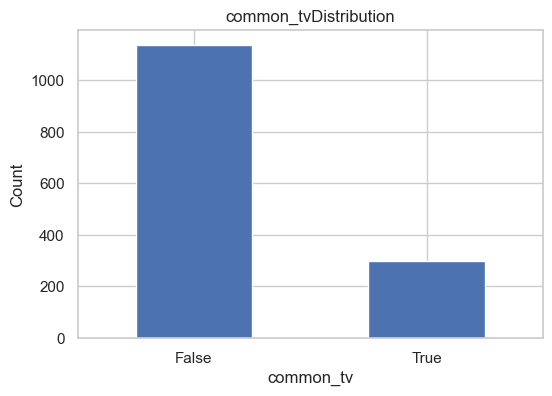

Unique Categories : [False  True]
Missing Values : 0

===== room_cleaning =====


,Count,Percentage
room_cleaning,,
False,900,62.67
True,536,37.33


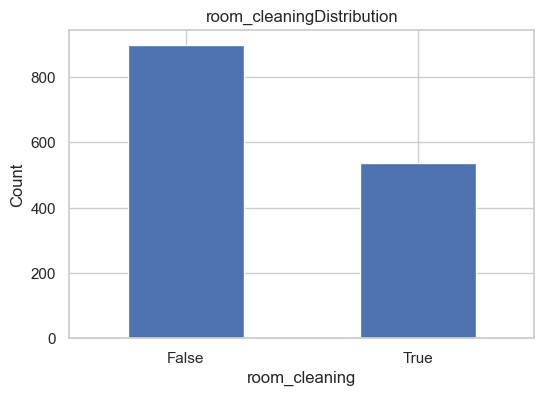

Unique Categories : [False  True]
Missing Values : 0

===== room_ac =====


,Count,Percentage
room_ac,,
False,1017,70.82
True,419,29.18


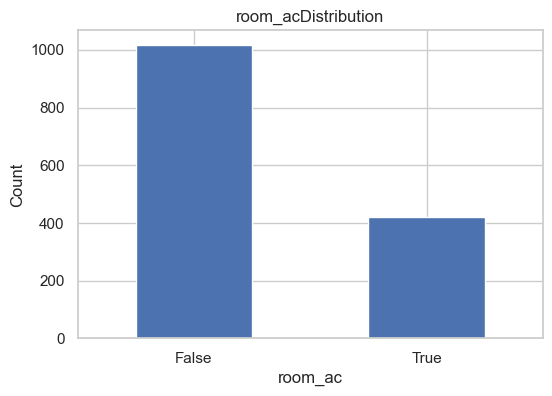

Unique Categories : [False  True]
Missing Values : 0

===== room_cupboard =====


,Count,Percentage
room_cupboard,,
False,984,68.52
True,452,31.48


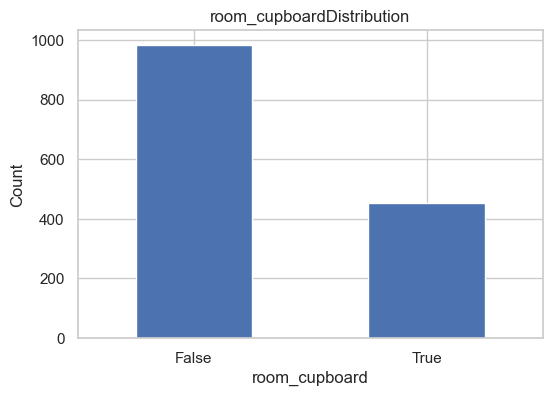

Unique Categories : [False  True]
Missing Values : 0

===== room_tv =====


,Count,Percentage
room_tv,,
False,1172,81.62
True,264,18.38


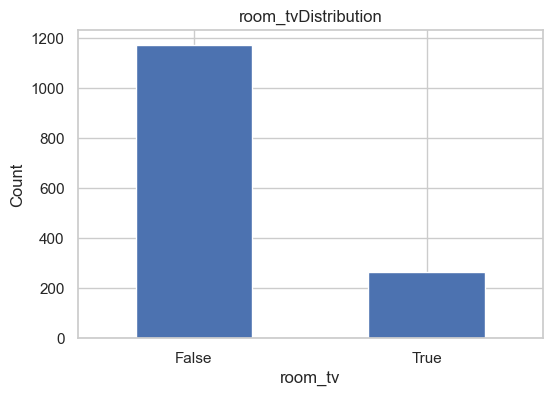

Unique Categories : [False  True]
Missing Values : 0

===== room_geyser =====


,Count,Percentage
room_geyser,,
False,1084,75.49
True,352,24.51


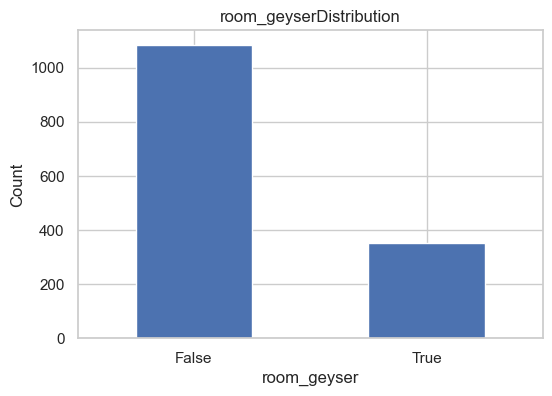

Unique Categories : [False  True]
Missing Values : 0

===== room_bedding =====


,Count,Percentage
room_bedding,,
False,983,68.45
True,453,31.55


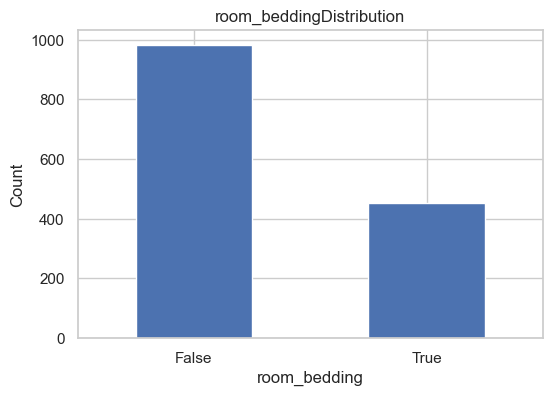

Unique Categories : [False  True]
Missing Values : 0

===== room_attached_bath =====


,Count,Percentage
room_attached_bath,,
False,971,67.62
True,465,32.38


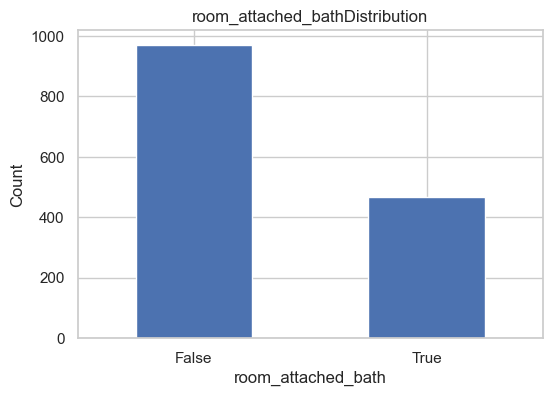

Unique Categories : [False  True]
Missing Values : 0


In [17]:
bool_col = df.select_dtypes(include=['bool']).columns.to_list()

for col in bool_col:
    analyze_categorical(df, column=(col))

# PHASE 3 — Univariate Analysis

## Summary Notebook

This notebook summarizes Phase 3 of the Chennai PG EDA workflow: **analyzing one feature at a time**.



## 1. Dataset Used

Phase 3 loads the cleaned dataset produced in Phase 2.

- Rows: **1,471**
- Columns: **31**
- Numerical features include latitude, longitude, transit score, lifestyle score, rent and deposit.
- Categorical features include locality, gender, available_for, occupancy and parking.
- Boolean columns represent PG amenities.


## 2. Numerical Univariate Analysis

For numerical columns, Phase 3 uses:

1. Histogram + KDE — understand the distribution.
2. Boxplot — understand spread, median and potential outliers.
3. Five-number summary — minimum, Q1, median, Q3 and maximum.
4. Mean, median, mode and standard deviation.
5. Skewness and kurtosis.
6. IQR-based outlier analysis.

### IQR method

`IQR = Q3 - Q1`

`Lower Fence = Q1 - 1.5 × IQR`

`Upper Fence = Q3 + 1.5 × IQR`


## 3. Rent Findings

| Metric | Value |
|---|---:|
| Mean | ₹7,779.39 |
| Median | ₹7,000 |
| Mode | ₹6,500 |
| Std Dev | ₹3,321.23 |
| Minimum | ₹1,500 |
| Q1 | ₹6,000 |
| Q3 | ₹8,500 |
| Maximum | ₹65,000 |
| Skewness | 4.92 |
| Kurtosis | 64.07 |
| IQR Outliers | 104 (7.07%) |

### Interpretation
Rent is strongly positively skewed. Most PGs are in the lower range, while a smaller premium segment creates the upper tail.

### Decision
Keep the outliers. They are treated as realistic premium PG listings rather than obvious errors. Skewness can be handled later during preprocessing, for example with `log1p` if appropriate.


## 4. Deposit Findings

| Metric | Value |
|---|---:|
| Mean | ₹6,104.53 |
| Median | ₹4,000 |
| Mode | ₹3,000 |
| Std Dev | ₹8,440.18 |
| Minimum | ₹0 |
| Q1 | ₹3,000 |
| Q3 | ₹6,000 |
| Maximum | ₹2,00,000 |
| Skewness | 10.84 |
| Kurtosis | 205.34 |
| IQR Outliers | 164 (11.15%) |

### Interpretation
Deposit is strongly right-skewed. The high values are treated as plausible premium/luxury PG deposits.

### Decision
Keep the outliers. No row-level removal is required at this stage.


## 5. Other Numerical Findings

- `transit_score` and `lifestyle_score` are described as roughly normally distributed.
- Their reported outlier statistics were identified as stale/wrong and should be re-run.
- No numerical feature requires row-level removal at this stage.
- Binary indicator columns should not be treated as continuous numerical variables for ordinary outlier analysis.


## 6. Categorical Analysis

Categorical columns are analyzed using:
- Number of unique categories
- Frequency of each category
- Percentage distribution
- Missing values
- Class imbalance


### `locality`

- 36 categories
- 0 missing values
- Tharamani: 240 (16.3%)
- OMR-Karapakkam: 232 (15.8%)
- Velachery: 192 (13.1%)
- The top three account for about 45% of listings.
- Around 24 localities have only 1–50 listings.

**Decision:** Keep `locality`. Smoothed target encoding was planned, with attention to the long tail and low-count categories.


### `gender`

- MALE: 770 (52.3%)
- FEMALE: 661 (44.9%)
- BOTH: 40 (2.7%)

**Decision:** Keep as-is. The Male/Female distribution is reasonably balanced and `BOTH` is retained as a valid small category.


### `available_for`

- Both: 1,307 (88.85%)
- Working Professional: 139 (9.45%)
- Student: 25 (1.70%)

**Decision:** Keep for now and re-check importance in Phase 4. Rename the value `Both` to a clearer label such as `Anyone` so it is not confused with `gender = BOTH`.


### `occupancy`

- THREE: 476 (32.4%)
- FOUR: 402 (27.3%)
- DOUBLE: 399 (27.1%)
- SINGLE: 194 (13.2%)

**Decision:** Keep it. Occupancy has a genuine order:

`Single < Double < Three < Four`

The notebook recommends preserving this ordinal meaning rather than treating it carelessly as an unordered category.


### `parking`

- Bike: 1,170 (79.5%)
- Bike and Car: 109 (7.4%)
- Car: 48 (3.3%)
- Missing: 144 (9.8%)

**Decision:** Keep the feature and handle its real missingness during preprocessing. The Phase 1 plan considered ordered parking levels such as none/bike/car/both.


## 7. Boolean / Amenity Analysis

All 15 Boolean amenity columns were checked using frequency analysis.

The main redundancy found was between `food_included` and the individual meal columns:

| Feature | Approximately True |
|---|---:|
| food_included | ~74% |
| breakfast | ~73% |
| lunch | ~71% |
| dinner | ~74% |

These features almost overlap.

**Decision:**
- Keep `food_included`
- Drop `breakfast`
- Drop `lunch`
- Drop `dinner`

This reduction was subsequently executed in the Phase 4 notebook.


## 8. Main Phase 3 Lessons

### Outlier ≠ error
A numerical value can be extreme but still be valid. Rent and deposit outliers were kept because they can represent premium PGs.

### Skewness ≠ bad data
Rent and deposit are strongly right-skewed. The notebook treats this as a preprocessing concern rather than automatically deleting rows.

### Imbalance matters
`locality` and `available_for` have strong category imbalance, which affects later encoding/modeling decisions.

### Redundant features should be reduced
`breakfast`, `lunch`, and `dinner` provide highly overlapping information with `food_included`.

### Domain meaning matters
`occupancy` has a natural order, so its real-world meaning should be preserved during encoding.


## 9. Phase 3 Decisions to Carry Forward

| # | Decision | Status |
|---|---|---|
| 1 | Rename `available_for` `Both` → `Anyone` | Planned |
| 2 | Keep `available_for`, re-check importance in Phase 4 | Watchlist |
| 3 | Drop `breakfast`, `lunch`, `dinner`; keep `food_included` | Done |
| 4 | Keep rent/deposit outliers as genuine premium-segment signal | Done |


## 10. Final Takeaway

**Phase 3 analyzes every feature individually and converts the observations into preprocessing decisions.**

The next phase is **Phase 4 — Bivariate Analysis**, where the relationship between each feature and the target variable `rent` is studied.
